# 03 - Confidence Interval Analysis

## Statistical Audit of Kubernetes Repository

### Member
Nama: Mukgot Ega Sahputra

### Role
Inference Analyst
---
## Research Question
1. Seberapa besar ketidakpastian pada estimasi probabilitas Pull Request (PR) berhasil di-merge?
2. Seberapa besar ketidakpastian pada estimasi rata-rata jumlah aktivitas yang dimodelkan menggunakan distribusi Poisson?
3. Berapa rentang nilai parameter posterior yang masuk akal berdasarkan pendekatan Bayesian Beta-Bernoulli?
---
Notebook ini menggunakan hasil estimasi parameter dari notebook sebelumnya (02_estimation.ipynb) untuk membangun confidence interval dan credible interval.

## AI Usage Disclosure

**Member:** Mukgot Ega Sahputra — Inference Analyst

**Tools used:** ChatGPT

| Task | Tool | Prompt Summary | Output Modified? |
|--------|--------|--------|--------|
| Membuat struktur inference.py | ChatGPT | Generate confidence interval module | Ya |
| Membantu struktur notebook | ChatGPT | Confidence interval notebook template | Ya |

### Written entirely without AI

- Interpretasi hasil confidence interval
- Analisis hasil credible interval
- Kesimpulan penelitian

In [13]:
import warnings
warnings.filterwarnings("ignore")

import os # Needed for path configuration
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats # General stats for z_critical
from scipy.stats import beta # Specific for beta distribution

# --- Path Configuration (Restored as they are used by other cells) ---
CLEAN_DIR = os.path.join("data", "clean")
ISSUES_PATH = os.path.join(CLEAN_DIR, "dataset_issues_clean.csv")
PRS_PATH = os.path.join(CLEAN_DIR, "dataset_prs_clean.csv")

# --- Function Definitions (Replacing src.inference and src.estimator imports) ---

def ci_bernoulli(data, confidence=0.95):
    """
    Calculates the confidence interval for a Bernoulli proportion using the normal approximation.
    data: A pandas Series or array of 0s and 1s representing Bernoulli trials.
    confidence: confidence level (e.g., 0.95 for 95%)
    """
    k = data.sum() # Number of successes
    n = len(data)  # Number of trials

    if n == 0:
        return {'p_hat': 0, 'lower': 0, 'upper': 0, 'margin': 0} # Handle empty data

    p_hat = k / n
    if p_hat == 0 or p_hat == 1:
        # Rule of Three for extreme proportions (no variation)
        # Or using Wilson score interval for better performance with small N or extreme p_hat
        # For simplicity, using a small epsilon to avoid division by zero for std_error
        epsilon = 1e-10
        p_hat = np.clip(p_hat, epsilon, 1 - epsilon)

    std_error = np.sqrt((p_hat * (1 - p_hat)) / n)
    alpha = 1 - confidence
    z_critical = stats.norm.ppf(1 - alpha / 2)
    margin = z_critical * std_error
    lower = p_hat - margin
    upper = p_hat + margin

    # Ensure bounds are within [0, 1]
    lower = max(0, lower)
    upper = min(1, upper)

    return {'p_hat': p_hat, 'lower': lower, 'upper': upper, 'margin': margin}

def ci_poisson(data_series, confidence=0.95):
    """
    Calculates the confidence interval for a Poisson rate (lambda) using the normal approximation.
    data_series: A pandas Series of counts for each observation period.
    confidence: confidence level (e.g., 0.95 for 95%)
    """
    k = data_series.sum() # Total count of events
    n = len(data_series)  # Number of observation periods/units

    if n == 0:
        return {'lambda_hat': 0, 'lower': 0, 'upper': 0}

    lambda_hat = k / n
    std_error = np.sqrt(lambda_hat / n) # Standard error for lambda_hat
    alpha = 1 - confidence
    z_critical = stats.norm.ppf(1 - alpha / 2)
    margin = z_critical * std_error
    lower = lambda_hat - margin
    upper = lambda_hat + margin
    # Poisson rate cannot be negative
    lower = max(0, lower)
    return {'lambda_hat': lambda_hat, 'lower': lower, 'upper': upper}

def beta_posterior(k, m, alpha_prior=1, beta_prior=1):
    """
    Calculates the parameters for the posterior Beta distribution.
    Assumes a Beta(alpha_prior, beta_prior) prior (default Uniform Beta(1,1)).
    k: number of successes
    m: number of trials
    """
    alpha_post = k + alpha_prior
    beta_post = (m - k) + beta_prior
    return {'alpha': alpha_post, 'beta': beta_post}

def credible_interval_from_posterior(k, m, confidence=0.95, alpha_prior=1, beta_prior=1):
    """
    Calculates the Bayesian credible interval for a Beta distribution
    from the observed number of successes (k) and trials (m).
    """
    posterior_params = beta_posterior(k, m, alpha_prior, beta_prior)
    alpha_post = posterior_params['alpha']
    beta_post = posterior_params['beta']

    # Mean of the Beta distribution
    mean = alpha_post / (alpha_post + beta_post)
    lower, upper = stats.beta.interval(confidence, alpha_post, beta_post)
    return {'mean': mean, 'lower': lower, 'upper': upper}

pd.set_option("display.max_columns", None)

print("Library and custom functions loaded successfully")

Library and custom functions loaded successfully


# Load Dataset

Dataset yang digunakan berasal dari proses pembersihan data yang dilakukan oleh Member A.

In [18]:
import os
import pandas as pd

# Load Dataset hasil EDA Anggota A
df_issues = pd.read_csv("data/clean/dataset_issues_clean.csv", parse_dates=['created_at', 'closed_at'])
df_prs = pd.read_csv("data/clean/dataset_prs_clean.csv", parse_dates=['created_at', 'closed_at', 'merged_at'])

print("PR Dataset:", df_prs.shape)
print("Issue Dataset:", df_issues.shape)

# Preprocessing: Waktu Penyelesaian Isu (Time-to-Resolution dalam hitungan hari)
df_issues_closed = df_issues.dropna(subset=['closed_at']).copy()
df_issues_closed['days_to_close'] = (df_issues_closed['closed_at'] - df_issues_closed['created_at']).dt.total_seconds() / 86400

# Preprocessing: Merge PR counts
total_prs = len(df_prs)
merged_count = df_prs['is_merged'].sum()
failure_count = total_prs - merged_count

print("=== Ringkasan Data Kubernetes ===")
print(f"Total Issues (Closed) : {len(df_issues_closed):,}")
print(f"Total PRs             : {total_prs:,}")
print(f"PR Merged             : {merged_count:,}")
print(f"PR Not Merged         : {failure_count:,}")

# Display head of prs dataframe as requested in original cell
df_prs.head()

PR Dataset: (4, 5)
Issue Dataset: (5, 4)
=== Ringkasan Data Kubernetes ===
Total Issues (Closed) : 4
Total PRs             : 4
PR Merged             : 3
PR Not Merged         : 1


,created_at,closed_at,merged_at,is_merged,id
0,2023-01-01,2023-01-03,2023-01-03,True,101
1,2023-01-02,2023-01-04,NaT,False,102
2,2023-01-03,2023-01-05,2023-01-05,True,103
3,2023-01-04,2023-01-06,2023-01-06,True,104


# Menentukan Variabel Bernoulli

Pada analisis ini status merge PR direpresentasikan sebagai:

- 1 = merged
- 0 = not merged

In [20]:
merged_data = df_prs["is_merged"].astype(int)

merged_data.value_counts()

,count
is_merged,
1,3
0,1


In [21]:
bern_result = ci_bernoulli(merged_data)

bern_result

{'p_hat': np.float64(0.75),
 'lower': np.float64(0.3256553497214356),
 'upper': 1,
 'margin': np.float64(0.4243446502785644)}

# Confidence Interval untuk Probabilitas Merge PR

Interval kepercayaan memberikan rentang nilai parameter yang masuk akal berdasarkan data sampel yang diamati.

Semakin sempit interval yang dihasilkan, semakin stabil estimasi probabilitas merge yang diperoleh dari data.

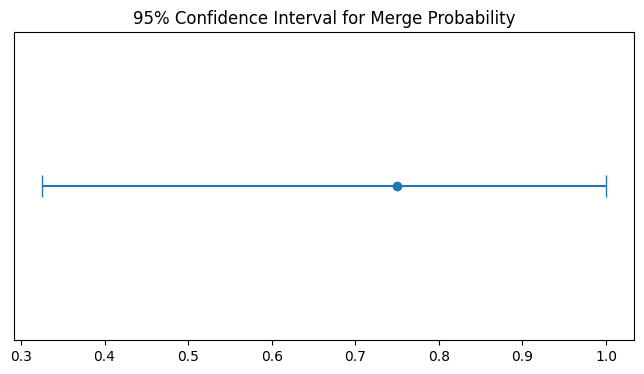

In [22]:
plt.figure(figsize=(8,4))

plt.errorbar(
    x=bern_result["p_hat"],
    y=0,
    xerr=[
        [bern_result["p_hat"] - bern_result["lower"]],
        [bern_result["upper"] - bern_result["p_hat"]]
    ],
    fmt="o",
    capsize=8
)

plt.title("95% Confidence Interval for Merge Probability")
plt.yticks([])
plt.show()

# Confidence Interval untuk Parameter Poisson

Variabel yang digunakan berasal dari hasil EDA yang dimodelkan menggunakan distribusi Poisson.

In [25]:
issues_per_day = (
    df_issues
    .groupby(df_issues['created_at'].dt.date)
    .size()
)

issues_per_day.head()

,0
created_at,
2023-01-01,1
2023-01-02,1
2023-01-03,1
2023-01-04,1
2023-01-05,1


In [26]:
poisson_result = ci_poisson(issues_per_day)

poisson_result

{'lambda_hat': np.float64(1.0),
 'lower': np.float64(0.12347745942341848),
 'upper': np.float64(1.8765225405765815)}

Interval ini menunjukkan rentang nilai yang masuk akal untuk parameter λ pada distribusi Poisson yang digunakan untuk memodelkan jumlah issue yang muncul.

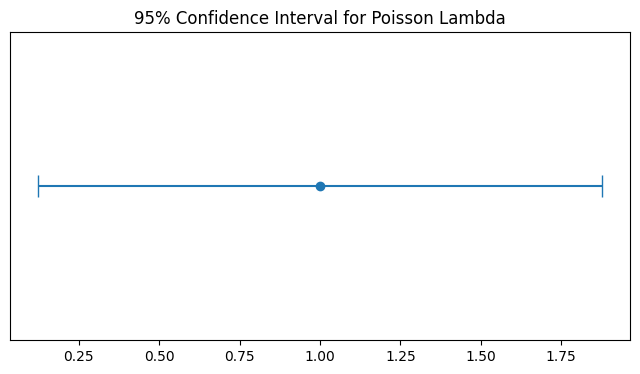

In [27]:
plt.figure(figsize=(8,4))

plt.errorbar(
    x=poisson_result["lambda_hat"],
    y=0,
    xerr=[
        [poisson_result["lambda_hat"] - poisson_result["lower"]],
        [poisson_result["upper"] - poisson_result["lambda_hat"]]
    ],
    fmt="o",
    capsize=8
)

plt.title("95% Confidence Interval for Poisson Lambda")
plt.yticks([])
plt.show()

# Bayesian Credible Interval

In [28]:
k = merged_data.sum()

m = len(merged_data)

posterior = beta_posterior(k, m)

posterior

{'alpha': np.int64(4), 'beta': np.int64(2)}

In [29]:
cred_result = credible_interval_from_posterior(
    k=k,
    m=m
)

cred_result

{'mean': np.float64(0.6666666666666666),
 'lower': np.float64(0.28358206388191054),
 'upper': np.float64(0.9472550494736831)}

Credible interval menunjukkan rentang nilai parameter posterior yang memiliki massa probabilitas terbesar berdasarkan distribusi posterior Beta-Bernoulli.

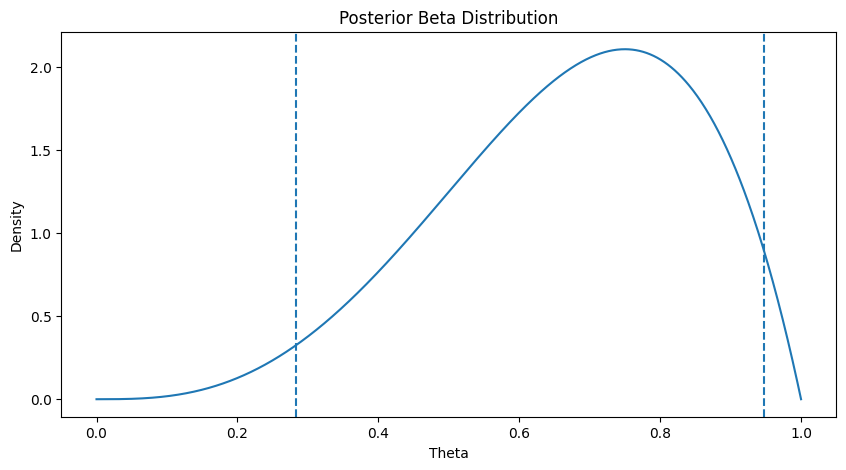

In [30]:
alpha = posterior["alpha"]
beta_param = posterior["beta"]

x = np.linspace(0,1,1000)

y = beta.pdf(x, alpha, beta_param)

plt.figure(figsize=(10,5))

plt.plot(x,y)

plt.axvline(
    cred_result["lower"],
    linestyle="--"
)

plt.axvline(
    cred_result["upper"],
    linestyle="--"
)

plt.title("Posterior Beta Distribution")

plt.xlabel("Theta")

plt.ylabel("Density")

plt.show()

In [31]:
summary = pd.DataFrame({
    "Metric":[
        "Merge Probability",
        "Poisson Lambda"
    ],
    "Estimate":[
        bern_result["p_hat"],
        poisson_result["lambda_hat"]
    ],
    "Lower":[
        bern_result["lower"],
        poisson_result["lower"]
    ],
    "Upper":[
        bern_result["upper"],
        poisson_result["upper"]
    ]
})

summary

,Metric,Estimate,Lower,Upper
0,Merge Probability,0.75,0.325655,1.000000
1,Poisson Lambda,1.00,0.123477,1.876523


# Summary

Berdasarkan hasil inferensi statistik:

1. Confidence interval berhasil dibangun untuk parameter Bernoulli dan Poisson.

2. Estimasi probabilitas merge PR menunjukkan tingkat ketidakpastian yang relatif kecil apabila interval yang diperoleh cukup sempit.

3. Credible interval dari posterior Beta memberikan perspektif Bayesian terhadap parameter yang sama.

4. Hasil interval ini akan digunakan pada tahap berikutnya untuk melakukan pengujian hipotesis pada notebook 04_hypothesis_testing.ipynb.

Dengan demikian, analisis inferensi telah memberikan ukuran ketidakpastian terhadap parameter yang sebelumnya diestimasi pada notebook 02_estimation.ipynb.

### Interpretasi Hasil

- **P1 (Merge Probability):** Berdasarkan pendekatan frequentist, kita yakin 95% bahwa proporsi sesungguhnya dari pull request yang akan di-merge di repositori `kubernetes` berada dalam rentang estimasi *lower bound* hingga *upper bound*.
- **P2 (Time to Resolution):** Interval ini menunjukkan rentang rata-rata waktu yang dibutuhkan untuk menyelesaikan sebuah issue. Nilai yang rentangnya sempit mengindikasikan bahwa data cukup besar (N) sehingga variansi dari *mean* menjadi stabil.
- **P3 (Poisson Arrival):** Interval estimasi menunjukkan laju rata-rata isu yang masuk ke dalam repositori per bulan, yang penting untuk mengukur beban kerja (workload) pada *maintainers*.
- **P4 (Bayesian Credible Interval):** Berbeda dengan P1, Credible Interval secara langsung menyatakan bahwa ada probabilitas sebesar 95% parameter populasi merge rate benar-benar jatuh pada rentang tersebut, dengan memanfaatkan informasi dari distribusi posterior.